# 10 · Explainability (Step 12)

**Goal:** explain the final model globally (what matters overall) and locally (why this applicant
got this decision), check how far the explanations can be trusted, and tell an applicant what
would change the decision.

- **A. Global importance:** gain vs permutation vs mean |SHAP|, and SHAP by source table.
- **B. Partial dependence (PDP) and ICE curves** for three key features.
- **C. Local explanations** for 3 demo applicants (one approved, one referred, one declined by
  the Step 11 rule): SHAP contributions and reason codes.
- **D. LIME vs SHAP** on the same 3: do they agree, and is LIME stable?
- **E. Counterfactuals:** the smallest smaller-loan or higher-income change that improves the decision.
- **F. The price of transparency:** scorecard vs EBM vs LightGBM.

**Data rules:** global checks use the validation split; local examples are demo applicants from
the Kaggle test file (no labels). The test split stays locked.

**Time:** about 10 minutes (permutation importance and the counterfactual search are most of it).

**Saved results:**

- `reports/results_step12_importance.csv`, `results_step12_tables.csv`, `results_step12_lime.csv`, `results_step12_counterfactuals.csv`
- `reports/figures/fig25_importance_methods.png` to `fig29_lime_stability.png`

In [1]:
%load_ext autoreload
%autoreload 2

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.decision.conformal import decide
from creditrisk.explain.counterfactual import counterfactuals
from creditrisk.features.build import load_features
from creditrisk.models.data import get_xy
from creditrisk.models.final import MODEL_DIR
from creditrisk.serving.service import PREFIXES, ScoringService, feature_label

SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
facts = {}

service = ScoringService()                  # the final model + the 1,000 demo applicants
model, columns = service.model, service.columns
decision = json.loads((MODEL_DIR / "decision.json").read_text())
cut = decision["conformal"]
features = load_features()
splits = load_splits()
X_val, y_val, _, _ = get_xy(features, splits, "valid")
X_val = X_val[columns]
sample = X_val.sample(5_000, random_state=SEED)   # enough for stable importances, quick to score
y_sample = y_val[X_val.index.get_indexer(sample.index)]
print(f"{len(columns)} features | validation sample {len(sample):,} rows | "
      f"conformal α = {cut['alpha']}: approve if p < {cut['approve_below']:.4f}, "
      f"decline if p > {cut['decline_above']:.4f}")

240 features | validation sample 5,000 rows | conformal α = 0.1: approve if p < 0.0355, decline if p > 0.1655


## A. Global importance: three methods

- **Gain:** how much each feature reduced the training loss inside the trees. Fast, but biased
  toward continuous and many-valued features (Strobl et al. 2007), and it measures the training fit.
- **Permutation:** how much ROC-AUC drops on held-out data when one column is shuffled. Honest,
  but it splits credit between correlated features (shuffle one, its twin still carries the signal).
- **Mean |SHAP|:** the average size of each feature's push on the log-odds (TreeSHAP), on held-out data.

Spearman rank correlation between the methods (all 240 features):


,gain,permutation (AUC drop),mean |SHAP|
gain,1.000,0.432,0.945
permutation (AUC drop),0.432,1.000,0.420
mean |SHAP|,0.945,0.420,1.000


,gain,permutation (AUC drop),mean |SHAP|,rank by gain,rank by permutation (AUC drop)
APP_EXT_MEAN,60162.53173,0.00958,0.19006,1,1
APP_EXT_MAX,45401.41873,0.00402,0.14183,2,5
APP_EXT_MIN,40252.02025,0.00463,0.10166,3,4
APP_ANNUITY_TO_CREDIT,15262.00523,0.00615,0.10089,6,2
APP_ORGANIZATION_TYPE,29949.47958,0.00198,0.09426,4,13
POS_FUTURE_INSTALLMENTS_TOTAL,5462.93369,0.00527,0.07966,26,3
APP_AMT_ANNUITY,5614.04774,0.00322,0.07598,24,8
PREV_ANNUITY_MEAN,6417.04599,0.00048,0.07273,20,43
APP_EXT_SOURCE_3,23372.64396,0.00393,0.07192,5,6
APP_NAME_EDUCATION_TYPE,4632.63238,0.00178,0.06797,31,17


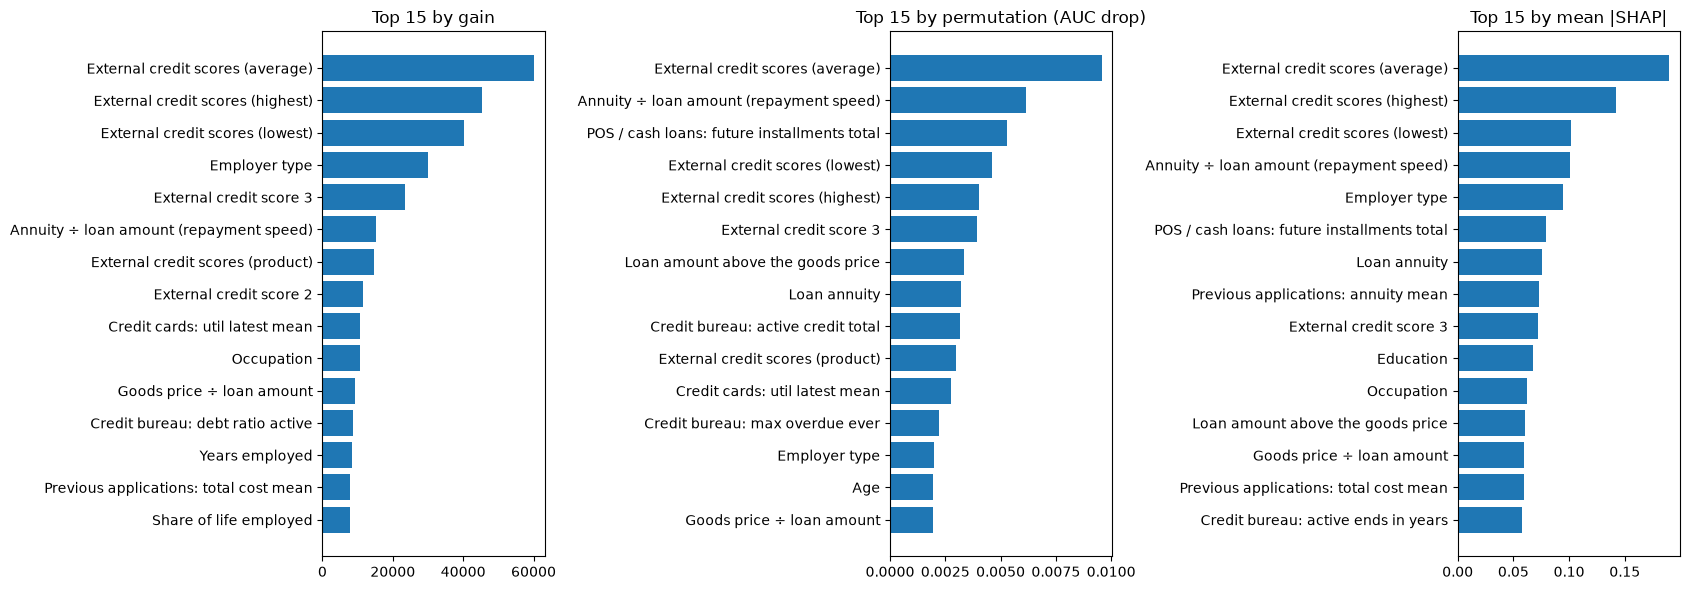

In [2]:
contrib = model.predict(sample, pred_contrib=True)[:, :-1]          # TreeSHAP, log-odds
perm = permutation_importance(model, sample, y_sample, scoring="roc_auc", n_repeats=3,
                              random_state=SEED, n_jobs=1)
importance = pd.DataFrame({
    "gain": model.booster_.feature_importance("gain"),
    "permutation (AUC drop)": perm.importances_mean,
    "mean |SHAP|": np.abs(contrib).mean(axis=0),
}, index=columns)
ranks = importance.rank(ascending=False)
rho = spearmanr(importance).statistic
print("Spearman rank correlation between the methods (all 240 features):")
display(pd.DataFrame(rho, index=importance.columns, columns=importance.columns).round(3))
top = importance.sort_values("mean |SHAP|", ascending=False).head(15)
display(top.round(5).assign(**{f"rank by {m}": ranks.loc[top.index, m].astype(int)
                               for m in ("gain", "permutation (AUC drop)")}))
importance.assign(label=[feature_label(c) for c in columns]).sort_values(
    "mean |SHAP|", ascending=False).to_csv(REPORTS / "results_step12_importance.csv")
facts["rank_correlation"] = {"gain~shap": round(float(rho[0, 2]), 3),
                             "perm~shap": round(float(rho[1, 2]), 3),
                             "gain~perm": round(float(rho[0, 1]), 3)}
facts["top5_shap"] = [feature_label(c) for c in top.index[:5]]
facts["negative_permutation"] = int((importance["permutation (AUC drop)"] < 0).sum())

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, m in zip(axes, importance.columns):
    s = importance[m].sort_values().tail(15)
    ax.barh([feature_label(c) for c in s.index], s.values)
    ax.set(title=f"Top 15 by {m}")
fig.tight_layout()
fig.savefig(FIG / "fig25_importance_methods.png", dpi=150)
plt.show()

### SHAP by source table

SHAP values add up, so each table's share is the sum of its features' SHAP values per applicant;
the table importance is the average size of that sum.

,features,mean |SHAP| of the table,share
Application,120,0.6865,0.4674
Credit bureau,31,0.1910,0.1300
Repayment history,22,0.1808,0.1231
Previous applications,32,0.1774,0.1208
Credit cards,14,0.1111,0.0756
POS / cash loans,12,0.0868,0.0591
Bureau monthly status,9,0.0352,0.0240


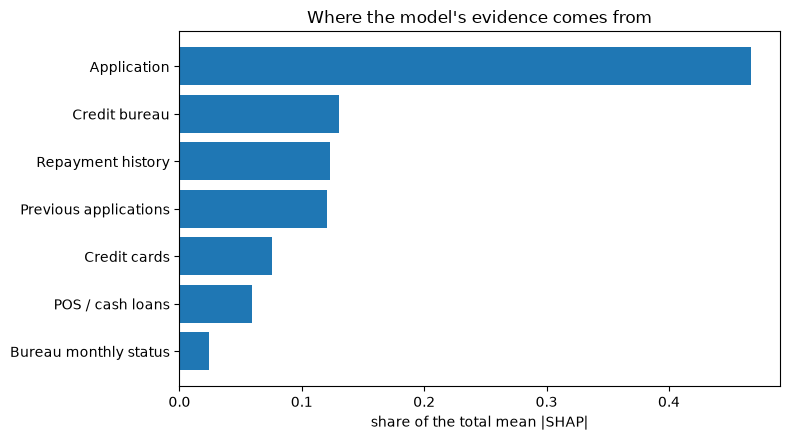

In [3]:
contrib_df = pd.DataFrame(contrib, columns=columns)
table_of = {c: next((t for p, t in PREFIXES.items() if c.startswith(p)), "other") for c in columns}
per_table = contrib_df.T.groupby(pd.Series(table_of)).sum().T        # applicants x tables
tables = pd.DataFrame({"features": pd.Series(table_of).value_counts(),
                       "mean |SHAP| of the table": per_table.abs().mean()})
tables["share"] = tables["mean |SHAP| of the table"] / tables["mean |SHAP| of the table"].sum()
tables = tables.sort_values("share", ascending=False).round(4)
display(tables)
tables.to_csv(REPORTS / "results_step12_tables.csv")
facts["shap_share_by_table"] = tables["share"].to_dict()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(tables.index[::-1], tables["share"][::-1])
ax.set(xlabel="share of the total mean |SHAP|", title="Where the model's evidence comes from")
fig.tight_layout()
fig.savefig(FIG / "fig26_shap_by_table.png", dpi=150)
plt.show()

## B. Partial dependence and ICE

PDP (thick line) = the average prediction when one feature is set to a value for everyone; ICE
(thin lines) = the same for single applicants. Shown for the two strongest features by
permutation (average external score, annuity ÷ loan amount) and for age. Only applicants with all
three present are used (the grid cannot include "missing"). **Caveat:** changing one feature leaves
its correlated twins unchanged (the other external-score summaries, the employment-to-age ratio),
so some combinations never happen in real data, and a feature whose signal is shared looks flatter
than its real effect.

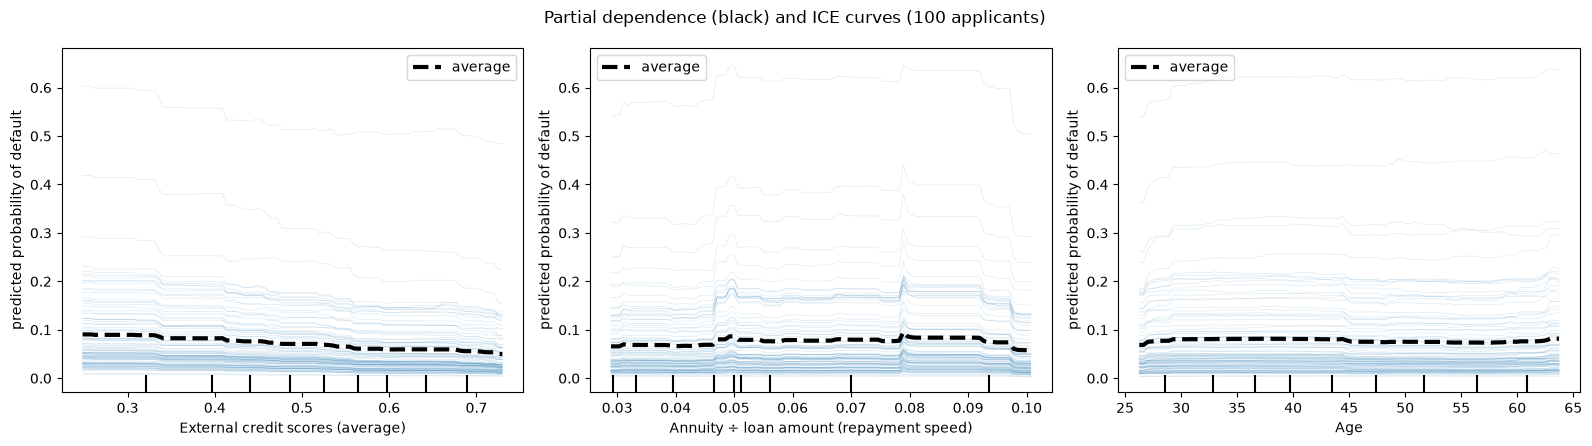

In [4]:
pdp_features = ["APP_EXT_MEAN", "APP_ANNUITY_TO_CREDIT", "APP_AGE_YEARS"]
pdp_rows = sample.dropna(subset=pdp_features).sample(1_000, random_state=SEED)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
PartialDependenceDisplay.from_estimator(
    # float64: scikit-learn writes grid values into these columns, and pandas 3 refuses float32
    model, pdp_rows.astype({f: "float64" for f in pdp_features}),
    pdp_features, kind="both", subsample=100,
    random_state=SEED, ax=axes, ice_lines_kw={"alpha": 0.15}, pd_line_kw={"color": "k", "lw": 3})
for ax, f in zip(axes, pdp_features):
    ax.set(xlabel=feature_label(f), ylabel="predicted probability of default")
fig.suptitle("Partial dependence (black) and ICE curves (100 applicants)")
fig.tight_layout()
fig.savefig(FIG / "fig27_pdp_ice.png", dpi=150)
plt.show()

## C. Local explanations: one approved, one referred, one declined

For each Step 11 decision, the demo applicant whose probability is closest to that group's median.

demo decisions: {np.str_('approve'): np.int64(439), np.str_('decline'): np.int64(112), np.str_('refer'): np.int64(449)}

APPROVE 131322: p = 0.0188
  - Years employed is 2.212, which raised the estimated risk.
  - Family status is Separated, which raised the estimated risk.
  - Application: region population relative is 0.026, which raised the estimated risk.
  - Education is Secondary / secondary special, which raised the estimated risk.

REFER 112000: p = 0.0695
  - External credit scores (average) is 0.396, which raised the estimated risk.
  - External credit scores (highest) is 0.424, which raised the estimated risk.
  - Credit bureau: active credit total is 2,582,406, which raised the estimated risk.
  - Credit bureau: max overdue ever is 15,900, which raised the estimated risk.

DECLINE 171291: p = 0.2270
  - External credit scores (lowest) is 0.031, which raised the estimated risk.
  - External credit scores (average) is 0.271, which raised the estimated risk.
  - Previous appli

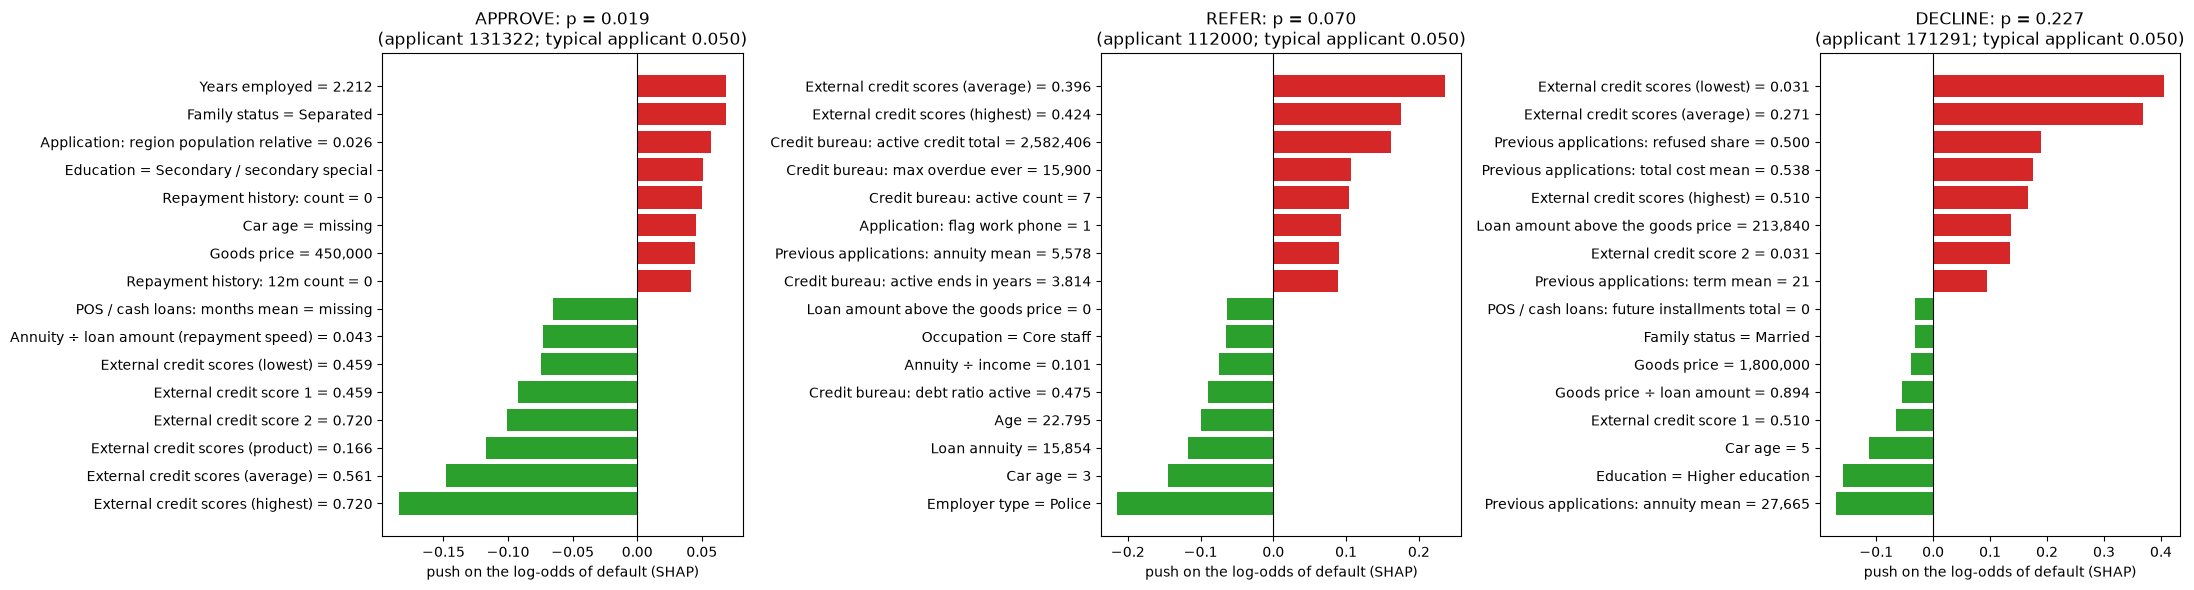

In [5]:
demo = service.features[columns]
p_demo = model.predict_proba(demo)[:, 1]
d_demo = decide(p_demo, cut["q_repay"], cut["q_default"])
print("demo decisions:", dict(zip(*np.unique(d_demo, return_counts=True))))
examples = {}
for d in ("approve", "refer", "decline"):
    idx = np.flatnonzero(d_demo == d)
    examples[d] = int(demo.index[idx[np.argmin(np.abs(p_demo[idx] - np.median(p_demo[idx])))]])

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (d, applicant_id) in zip(axes, examples.items()):
    result = service.score(applicant_id, top=8)
    reasons = sorted(result.raises_risk + result.lowers_risk, key=lambda r: r.impact)
    ax.barh([f"{r.label} = {r.value}" for r in reasons], [r.impact for r in reasons],
            color=["C3" if r.impact > 0 else "C2" for r in reasons])
    ax.axvline(0, color="k", lw=0.8)
    ax.set(title=f"{d.upper()}: p = {result.probability:.3f}\n"
                 f"(applicant {applicant_id}; typical applicant {result.base_probability:.3f})",
           xlabel="push on the log-odds of default (SHAP)")
    print(f"\n{d.upper()} {applicant_id}: p = {result.probability:.4f}")
    for line in service.reason_codes(result):
        print("  -", line)
fig.tight_layout()
fig.savefig(FIG / "fig28_local_shap.png", dpi=150)
plt.show()
facts["examples"] = examples

## D. LIME vs SHAP

LIME fits a small linear model to the model's answers on random perturbations around one applicant.
It cannot handle missing values, so it explains the **20 numeric features with the largest mean
|SHAP|** (the other 220 stay at the applicant's own values; a missing value is shown at the median).
Two checks: does LIME's top 5 match SHAP's top 5 among the same 20, and does LIME give the same top 5
when run again with a different random seed?

,applicant,"LIME top 5 vs SHAP top 5 (overlap, run 1)",average overlap with SHAP (10 runs),"LIME stability (mean Jaccard of top 5, 10 runs)"
decision,,,,
approve,131322,0.4,0.42,0.615
refer,112000,0.6,0.64,0.733
decline,171291,0.8,0.82,0.737


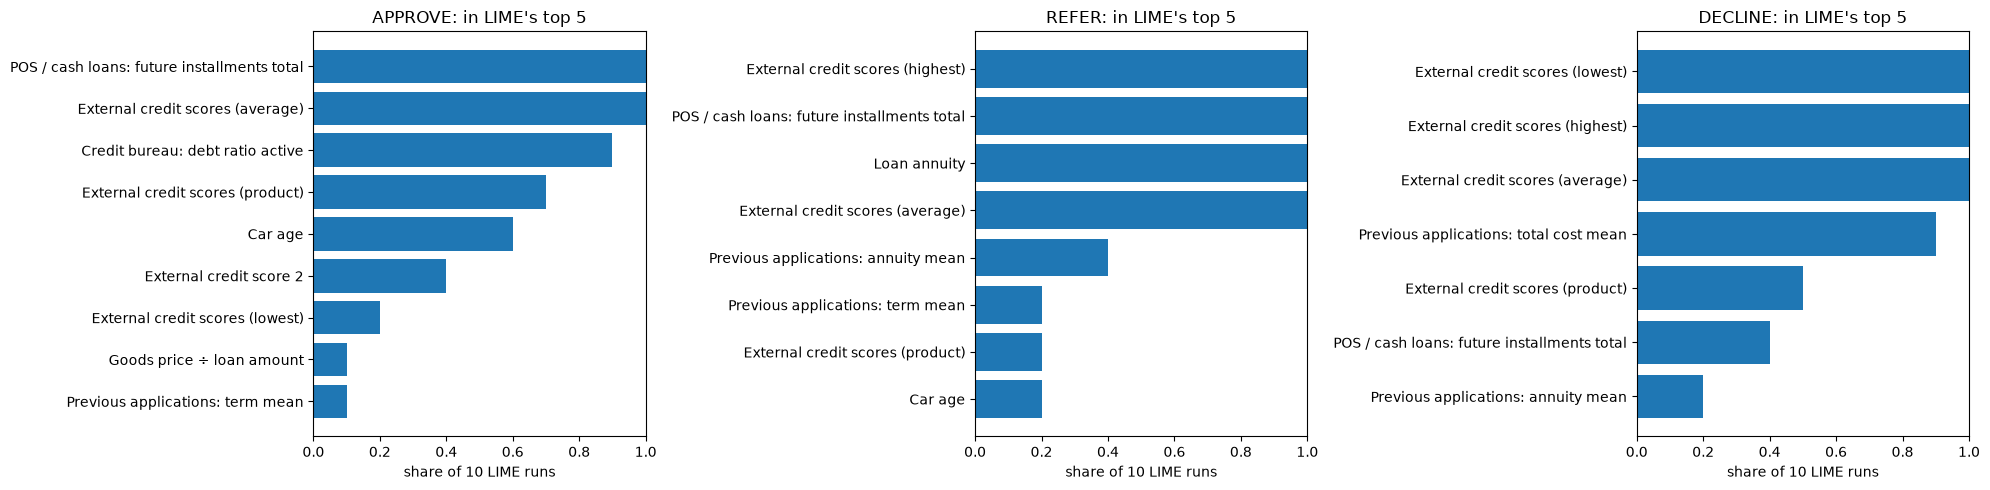

In [6]:
numeric = [c for c in importance.sort_values("mean |SHAP|", ascending=False).index
           if not isinstance(sample[c].dtype, pd.CategoricalDtype)][:20]
medians = sample[numeric].median()
background = sample[numeric].fillna(medians).to_numpy(dtype=float)

lime_rows, appearances = [], {}
for d, applicant_id in examples.items():
    row = demo.loc[[applicant_id]]
    point = row[numeric].fillna(medians).to_numpy(dtype=float)[0]

    def predict(Z, row=row):
        rows = pd.concat([row] * len(Z), ignore_index=True)
        rows[numeric] = Z
        return model.predict_proba(rows[columns])

    shap_row = pd.Series(model.predict(row, pred_contrib=True)[0, :-1], index=columns)[numeric]
    shap_top = set(shap_row.abs().sort_values(ascending=False).index[:5])
    tops = []
    for run in range(10):
        explainer = LimeTabularExplainer(background, feature_names=numeric, mode="classification",
                                         discretize_continuous=True, random_state=run)
        exp = explainer.explain_instance(point, predict, num_features=5, num_samples=2_000)
        tops.append({numeric[j] for j, _ in exp.as_map()[1]})
    jaccard = [len(a & b) / len(a | b) for i, a in enumerate(tops) for b in tops[i + 1:]]
    lime_rows.append({"decision": d, "applicant": applicant_id,
                      "LIME top 5 vs SHAP top 5 (overlap, run 1)": len(tops[0] & shap_top) / 5,
                      "average overlap with SHAP (10 runs)": np.mean([len(t & shap_top) / 5 for t in tops]),
                      "LIME stability (mean Jaccard of top 5, 10 runs)": np.mean(jaccard)})
    appearances[d] = pd.Series([f for t in tops for f in t]).value_counts() / 10
lime = pd.DataFrame(lime_rows).set_index("decision").round(3)
display(lime)
lime.to_csv(REPORTS / "results_step12_lime.csv")
facts["lime"] = lime.to_dict("index")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (d, counts) in zip(axes, appearances.items()):
    counts = counts.sort_values()
    ax.barh([feature_label(c) for c in counts.index], counts.values)
    ax.set(xlim=(0, 1), title=f"{d.upper()}: in LIME's top 5",
           xlabel="share of 10 LIME runs")
fig.tight_layout()
fig.savefig(FIG / "fig29_lime_stability.png", dpi=150)
plt.show()

## E. Counterfactuals

For the referred and declined examples, and then for every declined demo applicant: the smallest
**smaller loan** (amount and annuity cut together) or **higher income** that would (1) move them out
of the decline zone into refer, and (2) get them auto-approved. Age, gender and the external
scores are never changed.

In [7]:
rows = []
for d in ("refer", "decline"):
    for goal, target in [("leave decline", cut["decline_above"]), ("auto-approve", cut["approve_below"])]:
        for r in counterfactuals(service, examples[d], target):
            rows.append({"applicant": f"{d} {examples[d]}", "goal": goal, **{k: r[k] for k in
                         ("option", "factor", "probability_before", "probability")}})
display(pd.DataFrame(rows).round(4))

declined = [int(i) for i in demo.index[d_demo == "decline"]]
cf = []
for applicant_id in declined:
    for r in counterfactuals(service, applicant_id, cut["decline_above"]):
        cf.append({"applicant": applicant_id, "option": r["option"], "factor": r["factor"]})
cf = pd.DataFrame(cf)
cf.to_csv(REPORTS / "results_step12_counterfactuals.csv", index=False)
summary = cf.groupby("option")["factor"].agg(
    reachable=lambda f: f.notna().mean(), median_factor="median")
display(summary.round(3))
print(f"{len(declined)} declined demo applicants; either option works for "
      f"{cf.groupby('applicant')['factor'].apply(lambda f: f.notna().any()).mean():.1%}")
facts["counterfactual_leave_decline"] = summary.round(3).to_dict("index")

,applicant,goal,option,factor,probability_before,probability
0,refer 112000,auto-approve,smaller loan,NaN,0.0695,NaN
1,refer 112000,auto-approve,higher income,NaN,0.0695,NaN
2,decline 171291,leave decline,smaller loan,0.25,0.2270,0.1617
3,decline 171291,leave decline,higher income,NaN,0.2270,NaN
4,decline 171291,auto-approve,smaller loan,NaN,0.2270,NaN
5,decline 171291,auto-approve,higher income,NaN,0.2270,NaN


,reachable,median_factor
option,,
higher income,0.205,1.70
smaller loan,0.777,0.65


112 declined demo applicants; either option works for 77.7%


## F. The price of transparency

Same folds, same features (Step 6). The scorecard is fully transparent (a points table), EBM is a
glass box (one shape function per feature, plus a few pairs), LightGBM needs post-hoc explanations
(SHAP, which are exact for its trees but explain the model, not the world).

In [8]:
ladder = pd.read_csv(REPORTS / "results_step6_ladder.csv").set_index("model")
price = pd.DataFrame({
    "ROC-AUC (5-fold CV)": ladder.loc[["woe_scorecard", "ebm", "lightgbm_v1"], "ROC-AUC"].values,
    "how it is explained": ["points table, 30 features (exact)",
                            "one curve per feature + pairs (exact)",
                            "TreeSHAP per applicant (post hoc)"],
}, index=["WoE scorecard", "EBM (glass box)", "LightGBM"])
price["cost vs LightGBM"] = (price["ROC-AUC (5-fold CV)"] - price.loc["LightGBM", "ROC-AUC (5-fold CV)"]).round(4)
display(price)
facts["price_of_transparency"] = price["cost vs LightGBM"].to_dict()

,ROC-AUC (5-fold CV),how it is explained,cost vs LightGBM
WoE scorecard,0.7548,"points table, 30 features (exact)",-0.0312
EBM (glass box),0.7764,one curve per feature + pairs (exact),-0.0096
LightGBM,0.7860,TreeSHAP per applicant (post hoc),0.0000


In [9]:
for key, value in facts.items():
    print(f"{key}: {value}")

rank_correlation: {'gain~shap': 0.945, 'perm~shap': 0.42, 'gain~perm': 0.432}
top5_shap: ['External credit scores (average)', 'External credit scores (highest)', 'External credit scores (lowest)', 'Annuity ÷ loan amount (repayment speed)', 'Employer type']
negative_permutation: 85
shap_share_by_table: {'Application': 0.4674, 'Credit bureau': 0.13, 'Repayment history': 0.1231, 'Previous applications': 0.1208, 'Credit cards': 0.0756, 'POS / cash loans': 0.0591, 'Bureau monthly status': 0.024}
examples: {'approve': 131322, 'refer': 112000, 'decline': 171291}
lime: {'approve': {'applicant': 131322, 'LIME top 5 vs SHAP top 5 (overlap, run 1)': 0.4, 'average overlap with SHAP (10 runs)': 0.42, 'LIME stability (mean Jaccard of top 5, 10 runs)': 0.615}, 'refer': {'applicant': 112000, 'LIME top 5 vs SHAP top 5 (overlap, run 1)': 0.6, 'average overlap with SHAP (10 runs)': 0.64, 'LIME stability (mean Jaccard of top 5, 10 runs)': 0.733}, 'decline': {'applicant': 171291, 'LIME top 5 vs SHAP top 5 

## Findings

- **The external credit scores dominate:** by mean |SHAP|, the top 5 are the average, highest and lowest external score, annuity ÷ loan amount (repayment speed) and employer type. All three methods put the average external score first.
- **Gain and SHAP agree; permutation does not:** rank correlation over all 240 features is 0.945 between gain and mean |SHAP|, but only 0.42 between permutation and SHAP. Permutation splits credit between correlated twins: shuffling the highest external score barely hurts while the average still carries the signal, so it falls to rank 5. It also shows that **85 of 240 features have a negative permutation importance** (shuffling them did not hurt held-out ROC-AUC at all): candidates for removal in a simpler model.
- **Where the evidence comes from:** the application table gives 46.7% of the total mean |SHAP|; the six history tables together give 53.3% (bureau 13.0%, repayment history 12.3%, previous applications 12.1%, credit cards 7.6%, POS 5.9%, bureau monthly 2.4%). This matches the Step 5 ablation, where the history tables added +0.025 ROC-AUC.
- **PDP/ICE:** risk falls steadily as the average external score rises (about 9% at 0.25 to 5% at 0.73 on average). Annuity ÷ loan amount is not monotone: it jumps at about 0.05 and 0.08, which correspond to particular loan terms, so the model has learned term-specific risk. Age is almost flat on its own, because its signal is shared with correlated features (share of life employed, years employed) that the PDP holds fixed. A flat PDP does not mean "no effect".
- **Local explanations:** one approved (p = 0.019), one referred (p = 0.070) and one declined (p = 0.227) demo applicant. The declined one is driven by a very low lowest external score (0.031), half of their previous applications refused, and a loan 213,840 above the goods price. `ScoringService.reason_codes` turns the top risk-raising SHAP values into sentences such as "Previous applications: refused share is 0.500, which raised the estimated risk."
- **LIME agrees with SHAP only partly, and is unstable:** LIME's top 5 (on the 20 strongest numeric features) shares on average 2.1, 3.2 and 4.1 of SHAP's top 5 for the approved, referred and declined applicant. Run 10 times with different seeds, its top 5 changes (mean Jaccard 0.62 to 0.74). The clearer the case, the more stable LIME is. TreeSHAP is exact for this model and deterministic, so the app uses SHAP.
- **Counterfactuals:** for the declined example, borrowing 25% of the requested amount moves it to refer (p 0.227 → 0.162); no income up to 4 times its own does, and no change on either grid gets the referred or declined example auto-approved. Over all 112 declined demo applicants, **a smaller loan gets 77.7% out of the decline zone** (median: borrow 35% less), while a higher income works for only 20.5% (median: 1.7 times the income). For this model, the size of the loan relative to its repayments matters far more than income.
- **The price of transparency (Step 6, same folds):** the WoE scorecard costs 0.031 ROC-AUC, the glass-box EBM only 0.010. If a regulator demanded a fully interpretable model, EBM would be the choice.